In [2]:
# Mount Drive only when running in Colab; skip on local VS Code.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False
    print("Running outside Colab; using local workspace paths.")

Mounted at /content/drive


# Bangladesh National Election 2026 – Analytics Pipeline

**Course:** CSE488 | **Date:** 2026-02-27

This notebook implements the full big-data analytics pipeline using **Apache Spark (PySpark)** and **Spark MLlib**.

### Pipeline Stages
1. **Spark Setup** – Install PySpark, initialise SparkSession
2. **Data Ingestion** – Load election, BBS, and HDX datasets into Spark DataFrames
3. **Data Engineering** – Cleaning, joins, feature engineering (Spark SQL)
4. **MLlib Analytics** – Correlation, Regression, Classification, Clustering
5. **Export** – Persist ML artifacts for dashboard consumption

---
## Stage 1 — Spark Environment Setup

In [3]:
# ── 1.1  Install PySpark (Colab already has Java pre-installed) ────────────────
!pip install -q pyspark==3.5.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 1.4 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 15.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.2 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.0 which is incompatible.


In [4]:
# ── 1.2  Initialise SparkSession ──────────────────────────────────────────────
from pyspark.sql import SparkSession

spark = (SparkSession.builder
    .appName("BD-Election-2026-Analytics")
    .master("local[*]")                          # use all available Colab cores
    .config("spark.driver.memory", "8g")         # Colab standard runtime ≈ 12 GB RAM
    .config("spark.sql.shuffle.partitions", "8") # keep small; single-node
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY")
    .getOrCreate())

spark.sparkContext.setLogLevel("WARN")           # suppress INFO noise

print(f"Spark version : {spark.version}")
print(f"App name      : {spark.sparkContext.appName}")
print(f"Master        : {spark.sparkContext.master}")
print(f"Cores         : {spark.sparkContext.defaultParallelism}")
spark

Spark version : 3.5.0
App name      : BD-Election-2026-Analytics
Master        : local[*]
Cores         : 2


In [5]:
import os
if IN_COLAB:
    os.listdir('/content/drive/MyDrive/Election-Data/')
else:
    os.listdir('.')

---
## Stage 2 — Data Ingestion & Engineering

### 2A – Load raw datasets into Spark DataFrames
- **Election results**: per-candidate rows with constituency, party, votes, district, division
- **Socio-economic (HDX/BBS)**: district-level census indicators (445 columns → select key features)

In [6]:
# -- 2A.1  Load Election Results -----------------------------------------------
DATA_ROOT = os.environ.get("DATA_ROOT", "data_science/data")
if IN_COLAB and DATA_ROOT == "data_science/data":
    DATA_ROOT = "/content/drive/MyDrive/Election-Data/data"
print(f"DATA_ROOT: {DATA_ROOT}")

election_raw = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(f"{DATA_ROOT}/raw/news_scrape/daily_star_candidates_2026-02-20.csv"))

print(f"Election rows : {election_raw.count()}")
print(f"Columns       : {len(election_raw.columns)}")
election_raw.printSchema()
election_raw.show(5, truncate=30)

DATA_ROOT: /content/drive/MyDrive/Election-Data/data
Election rows : 2004
Columns       : 13
root
 |-- alliance: string (nullable = true)
 |-- candidate_count: integer (nullable = true)
 |-- candidate_name: string (nullable = true)
 |-- constituency: string (nullable = true)
 |-- district: string (nullable = true)
 |-- division: string (nullable = true)
 |-- is_winner: boolean (nullable = true)
 |-- page_title: string (nullable = true)
 |-- party: string (nullable = true)
 |-- scraped_at: timestamp (nullable = true)
 |-- source: string (nullable = true)
 |-- url: string (nullable = true)
 |-- votes: integer (nullable = true)

+--------+---------------+-----------------------------+------------+--------+--------+---------+------------------------------+--------------------------+-----------------------+----------+------------------------------+------+
|alliance|candidate_count|               candidate_name|constituency|district|division|is_winner|                    page_title|         

In [7]:
# ── 2A.2  Load Socio-Economic (HDX/BBS Census) Data ───────────────────────────
# The HDX dataset has 445 columns — select only the ones relevant for ML features.

SOCIO_COLS_KEEP = [
    # Keys
    "Division", "District", "District_Geocode",
    # Demographics
    "Population_Total", "Household_Total", "`Population Density`",
    # Urban / Rural population
    "`Population by Sex, Dist & Loca_Population_Total_#`",
    "`Population by Sex, Dist & Loca_Population_rural_Total_#`",
    "`Population by Sex, Dist & Loca_Population_Urban_Total_#`",
    # Male / Female population (for sex demography analysis)
    "`Population by Sex, Dist & Loca_Population_Male_#`",
    "`Population by Sex, Dist & Loca_Population_Female_#`",
    # Literacy
    "`Literacy Rate_7year+_Overall`", "`Literacy Rate_7year+_Male`", "`Literacy Rate_7year+_Female`",
    # Internet penetration
    "`%_Inernet_Total_5year+`", "`%_Inernet_Male_5year+`", "`%_Inernet_Female_5year+`",
    # Mobile phone usage
    "`%_Mobile Phone_Total_5year+`",
    # Employment
    "`Overall_Employed_Working_Status_5 Year+_#`",
    "`Overall_Looking for work_Working_Status_5 Year+_#`",
    # Youth NEET
    "`15-24 Years NEET_%_Overall`",
    # Financial inclusion
    "`%_Have financial account_Overall`",
    # Religion (majority share)
    "`Population by Religion, Sex_# Total_Muslim`",
    "`Population by Religion, Sex_# Total_Hindu`",
    # Sex ratio & dependency ratio (age structure proxy)
    "`Population Growth Rate, Sex Rat_Overall_Sex_Ratio`",
    "`Population Growth Rate, Sex Rat_Overall_Dependeny_Ratio`",
]

hdx_file = (f"{DATA_ROOT}/raw/HDX/"
            "bangladesh_bbs_population-and-housing-census-dataset_2022_admin-02"
            " - Merged_All_Table.csv")

socio_raw = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(hdx_file))

# Select only needed columns
socio_raw = socio_raw.selectExpr(*SOCIO_COLS_KEEP)

print(f"Socio-econ rows : {socio_raw.count()}")
print(f"Columns kept    : {len(socio_raw.columns)}")
socio_raw.printSchema()
socio_raw.show(5, truncate=25)

Socio-econ rows : 67
Columns kept    : 26
root
 |-- Division: string (nullable = true)
 |-- District: string (nullable = true)
 |-- District_Geocode: string (nullable = true)
 |-- Population_Total: string (nullable = true)
 |-- Household_Total: string (nullable = true)
 |-- Population Density: string (nullable = true)
 |-- Population by Sex, Dist & Loca_Population_Total_#: string (nullable = true)
 |-- Population by Sex, Dist & Loca_Population_rural_Total_#: string (nullable = true)
 |-- Population by Sex, Dist & Loca_Population_Urban_Total_#: integer (nullable = true)
 |-- Population by Sex, Dist & Loca_Population_Male_#: string (nullable = true)
 |-- Population by Sex, Dist & Loca_Population_Female_#: string (nullable = true)
 |-- Literacy Rate_7year+_Overall: double (nullable = true)
 |-- Literacy Rate_7year+_Male: double (nullable = true)
 |-- Literacy Rate_7year+_Female: double (nullable = true)
 |-- %_Inernet_Total_5year+: double (nullable = true)
 |-- %_Inernet_Male_5year+: doub

In [8]:
# ── 2A.3  Register Spark SQL Temp Views ────────────────────────────────────────
election_raw.createOrReplaceTempView("election_raw")
socio_raw.createOrReplaceTempView("socio_raw")

# Quick SQL sanity check
print("── Election: top 5 parties by seat count ──")
spark.sql("""
    SELECT party, COUNT(*) AS winners
    FROM election_raw
    WHERE is_winner = 'true'
    GROUP BY party
    ORDER BY winners DESC
    LIMIT 10
""").show(truncate=30)

print("── Socio-econ: sample districts ──")
spark.sql("""
    SELECT District, Population_Total, `Population Density`,
           `Literacy Rate_7year+_Overall` AS literacy_rate
    FROM socio_raw
    LIMIT 5
""").show(truncate=25)

── Election: top 5 parties by seat count ──
+------------------------------+-------+
|                         party|winners|
+------------------------------+-------+
|                           BNP|    209|
|    Bangladesh Jamaat-e-Islami|     68|
|                   Independent|      7|
| National Citizens Party - NCP|      6|
|    Bangladesh Khilafat Majlis|      2|
|           Ganosamhati Andolon|      1|
|    Islamic Andolon Bangladesh|      1|
|         Gono Odhikar Parishad|      1|
|Bangladesh National Party -...|      1|
|               Khilafat Majlis|      1|
+------------------------------+-------+

── Socio-econ: sample districts ──
+-------------------------+-------------------------+-------------------------+-------------+
|                 District|         Population_Total|       Population Density|literacy_rate|
+-------------------------+-------------------------+-------------------------+-------------+
|                     NULL|                     NULL|           

### 2B – Data Cleaning & Standardisation

- Cast types, handle nulls, deduplicate
- Standardise district names across datasets (3 known mismatches)
- Derive winner/runner-up per constituency

In [9]:
# ── 2B.1  Clean Election Data ──────────────────────────────────────────────────
from pyspark.sql import functions as F, Window

# 1) Cast votes to integer, is_winner to boolean
election = (election_raw
    .withColumn("votes", F.col("votes").cast("int"))
    .withColumn("is_winner", F.col("is_winner") == "true")
    .drop("page_title", "scraped_at", "source", "url")  # drop metadata cols
)

# 2) Standardise district names to match HDX/BBS spelling
DISTRICT_MAP = {
    "Coxs bazar":       "Cox's Bazar",
    "Chapainawabganj":  "Chapainababganj",
    "Jhalokathi":       "Jhalokati",
}

for old, new in DISTRICT_MAP.items():
    election = election.withColumn(
        "district",
        F.when(F.col("district") == old, new).otherwise(F.col("district"))
    )

# 3) Drop duplicates (same candidate + constituency)
before = election.count()
election = election.dropDuplicates(["constituency", "candidate_name"])
after = election.count()
print(f"Deduplication: {before} → {after} rows (removed {before - after})")

# 4) Derive per-constituency winner & runner-up using window functions
w = Window.partitionBy("constituency").orderBy(F.col("votes").desc())
election = election.withColumn("vote_rank", F.row_number().over(w))

election.createOrReplaceTempView("election")
election.filter(F.col("vote_rank") <= 2).show(10, truncate=25)

Deduplication: 2004 → 1998 rows (removed 6)
+--------+---------------+-------------------------+------------+---------+----------+---------+-------------------------+------+---------+
|alliance|candidate_count|           candidate_name|constituency| district|  division|is_winner|                    party| votes|vote_rank|
+--------+---------------+-------------------------+------------+---------+----------+---------+-------------------------+------+---------+
|  jamaat|              8|  Md. Mashiur Rahman Khan|  Bagerhat 1| Bagerhat|    Khulna|     true|Bangladesh Jamaat-e-Is...|117527|        1|
|  jamaat|              8|     Kapil Krishna Mandal|  Bagerhat 1| Bagerhat|    Khulna|    false|                      BNP|114323|        2|
|  jamaat|              4|Sheikh Manjurul Haque ...|  Bagerhat 2| Bagerhat|    Khulna|     true|Bangladesh Jamaat-e-Is...|117709|        1|
|  jamaat|              4|Sheikh Mohammad Zakir ...|  Bagerhat 2| Bagerhat|    Khulna|    false|                    

In [10]:
# ── 2B.2  Clean & Rename Socio-Economic Data ──────────────────────────────────
# Rename long column names to short, ML-friendly aliases
socio = (socio_raw
    .withColumnRenamed("Population Density", "pop_density")
    .withColumnRenamed("Population by Sex, Dist & Loca_Population_Total_#", "pop_total_loc")
    .withColumnRenamed("Population by Sex, Dist & Loca_Population_rural_Total_#", "pop_rural")
    .withColumnRenamed("Population by Sex, Dist & Loca_Population_Urban_Total_#", "pop_urban")
    .withColumnRenamed("Population by Sex, Dist & Loca_Population_Male_#", "pop_male")
    .withColumnRenamed("Population by Sex, Dist & Loca_Population_Female_#", "pop_female")
    .withColumnRenamed("Literacy Rate_7year+_Overall", "literacy_rate")
    .withColumnRenamed("Literacy Rate_7year+_Male", "literacy_male")
    .withColumnRenamed("Literacy Rate_7year+_Female", "literacy_female")
    .withColumnRenamed("%_Inernet_Total_5year+", "internet_pct")
    .withColumnRenamed("%_Inernet_Male_5year+", "internet_male_pct")
    .withColumnRenamed("%_Inernet_Female_5year+", "internet_female_pct")
    .withColumnRenamed("%_Mobile Phone_Total_5year+", "mobile_phone_pct")
    .withColumnRenamed("Overall_Employed_Working_Status_5 Year+_#", "employed_total")
    .withColumnRenamed("Overall_Looking for work_Working_Status_5 Year+_#", "looking_for_work")
    .withColumnRenamed("15-24 Years NEET_%_Overall", "neet_pct")
    .withColumnRenamed("%_Have financial account_Overall", "financial_account_pct")
    .withColumnRenamed("Population by Religion, Sex_# Total_Muslim", "pop_muslim")
    .withColumnRenamed("Population by Religion, Sex_# Total_Hindu", "pop_hindu")
    .withColumnRenamed("Population Growth Rate, Sex Rat_Overall_Sex_Ratio", "sex_ratio")
    .withColumnRenamed("Population Growth Rate, Sex Rat_Overall_Dependeny_Ratio", "dependency_ratio")
)

# Cast all numeric columns (inferSchema may miss some due to commas/spaces)
numeric_cols = [c for c in socio.columns if c not in ("Division", "District", "District_Geocode")]
for c in numeric_cols:
    socio = socio.withColumn(c, F.col(c).cast("double"))

# Null check per column
print("── Null counts per column ──")
socio.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in socio.columns]).show(vertical=True)

socio.createOrReplaceTempView("socio")
socio.show(5, truncate=20)

── Null counts per column ──
-RECORD 0--------------------
 Division              | 0   
 District              | 2   
 District_Geocode      | 2   
 Population_Total      | 3   
 Household_Total       | 3   
 pop_density           | 3   
 pop_total_loc         | 3   
 pop_rural             | 3   
 pop_urban             | 3   
 pop_male              | 3   
 pop_female            | 3   
 literacy_rate         | 3   
 literacy_male         | 3   
 literacy_female       | 3   
 internet_pct          | 3   
 internet_male_pct     | 3   
 internet_female_pct   | 3   
 mobile_phone_pct      | 3   
 employed_total        | 3   
 looking_for_work      | 3   
 neet_pct              | 3   
 financial_account_pct | 3   
 pop_muslim            | 3   
 pop_hindu             | 3   
 sex_ratio             | 3   
 dependency_ratio      | 3   

+------------+--------------------+--------------------+----------------+---------------+-----------+-------------+---------+---------+--------+----------+-----

In [11]:
# ── 2B.3  District Name Reconciliation Check ──────────────────────────────────
# Verify all election districts match a socio-economic district after cleaning.

election_districts = (spark.sql("SELECT DISTINCT district FROM election")
                      .rdd.flatMap(lambda x: x).collect())
socio_districts    = (spark.sql("SELECT DISTINCT District FROM socio")
                      .rdd.flatMap(lambda x: x).collect())

unmatched_election = set(election_districts) - set(socio_districts)
unmatched_socio    = set(socio_districts) - set(election_districts)

if unmatched_election:
    print(f"⚠  Election districts NOT in socio-econ: {unmatched_election}")
else:
    print("✓ All election districts found in socio-economic data")

if unmatched_socio:
    print(f"ℹ  Socio-econ districts with no election data: {unmatched_socio}")

print(f"\nElection districts: {len(election_districts)} | Socio-econ districts: {len(socio_districts)}")

✓ All election districts found in socio-economic data
ℹ  Socio-econ districts with no election data: {None, 'Toilet Facilities_Raw/Open/ Hanging Latrine (Permanent/ Temporary)_%'}

Election districts: 64 | Socio-econ districts: 66


### 2C – Joining Datasets & Feature Engineering (Spark SQL + DataFrame API)

- Build **constituency-level** summary from candidate-level election data
- Join with **district-level** socio-economic indicators
- Engineer ML features: `turnout_pct`, `winning_margin_pct`, `urbanization_index`, `competitiveness_index`

In [12]:
# ── 2C.1  Build Constituency-Level Summary (Spark SQL) ────────────────────────
# Aggregate candidate-level data to one row per constituency using Spark SQL.

constituency = spark.sql("""
    WITH ranked AS (
        SELECT *,
               ROW_NUMBER() OVER (PARTITION BY constituency ORDER BY votes DESC) AS rnk,
               SUM(votes)   OVER (PARTITION BY constituency) AS total_votes
        FROM election
    )
    SELECT
        constituency,
        district,
        division,
        alliance,

        -- Winner info (rank 1)
        MAX(CASE WHEN rnk = 1 THEN candidate_name END) AS winner_candidate,
        MAX(CASE WHEN rnk = 1 THEN party END)           AS winner_party,
        MAX(CASE WHEN rnk = 1 THEN votes END)           AS winner_votes,

        -- Runner-up info (rank 2)
        MAX(CASE WHEN rnk = 2 THEN candidate_name END) AS runner_up_candidate,
        MAX(CASE WHEN rnk = 2 THEN party END)           AS runner_up_party,
        MAX(CASE WHEN rnk = 2 THEN votes END)           AS runner_up_votes,

        -- Aggregates
        MAX(total_votes)    AS total_valid_votes,
        MAX(candidate_count) AS candidate_count

    FROM ranked
    GROUP BY constituency, district, division, alliance
    ORDER BY constituency
""")

constituency.createOrReplaceTempView("constituency")
print(f"Constituencies: {constituency.count()}")
constituency.show(5, truncate=22)

Constituencies: 299
+------------+---------+----------+--------+----------------------+----------------------+------------+----------------------+----------------------+---------------+-----------------+---------------+
|constituency| district|  division|alliance|      winner_candidate|          winner_party|winner_votes|   runner_up_candidate|       runner_up_party|runner_up_votes|total_valid_votes|candidate_count|
+------------+---------+----------+--------+----------------------+----------------------+------------+----------------------+----------------------+---------------+-----------------+---------------+
|  Bagerhat 1| Bagerhat|    Khulna|  jamaat|Md. Mashiur Rahman ...|Bangladesh Jamaat-e...|      117527|  Kapil Krishna Mandal|                   BNP|         114323|           231850|              8|
|  Bagerhat 2| Bagerhat|    Khulna|  jamaat|Sheikh Manjurul Haq...|Bangladesh Jamaat-e...|      117709|Sheikh Mohammad Zak...|                   BNP|          66409|           1841

In [13]:
# ── 2C.2  Join Election ↔ Socio-Economic (Spark SQL + DataFrame API) ──────────
# Join on district — constituency-level election data inherits district-level
# socio-economic indicators.
# NOTE: Explicitly select s.columns (excluding keys) to avoid ambiguous
#       column names — Spark's case-insensitive drop would remove c.district too.

joined = spark.sql("""
    SELECT c.*,
           s.Population_Total, s.Household_Total, s.pop_density,
           s.pop_total_loc, s.pop_rural, s.pop_urban,
           s.pop_male, s.pop_female,
           s.literacy_rate, s.literacy_male, s.literacy_female,
           s.internet_pct, s.internet_male_pct, s.internet_female_pct,
           s.mobile_phone_pct, s.employed_total, s.looking_for_work,
           s.neet_pct, s.financial_account_pct, s.pop_muslim, s.pop_hindu,
           s.sex_ratio, s.dependency_ratio
    FROM constituency c
    LEFT JOIN socio s ON c.district = s.District
""")

joined.createOrReplaceTempView("joined")
print(f"Joined rows: {joined.count()} | Columns: {len(joined.columns)}")

# Check for any constituencies that failed to join
orphans = joined.filter(F.col("literacy_rate").isNull()).select("constituency", "district")
if orphans.count() > 0:
    print("⚠  Constituencies without socio-economic match:")
    orphans.show()
else:
    print("✓ All constituencies matched socio-economic data")

joined.show(3, truncate=18)

Joined rows: 299 | Columns: 35
✓ All constituencies matched socio-economic data
+------------+--------+--------+--------+------------------+------------------+------------+-------------------+------------------+---------------+-----------------+---------------+----------------+---------------+-----------+-------------+---------+---------+--------+----------+-------------+-------------+---------------+------------+-----------------+-------------------+----------------+--------------+----------------+--------+---------------------+----------+---------+---------+----------------+
|constituency|district|division|alliance|  winner_candidate|      winner_party|winner_votes|runner_up_candidate|   runner_up_party|runner_up_votes|total_valid_votes|candidate_count|Population_Total|Household_Total|pop_density|pop_total_loc|pop_rural|pop_urban|pop_male|pop_female|literacy_rate|literacy_male|literacy_female|internet_pct|internet_male_pct|internet_female_pct|mobile_phone_pct|employed_total|looking_f

In [14]:
# -- 2C.3  Feature Engineering -------------------------------------------------
# Create derived features required by the analytics plan.

turnout_den_col = "registered_voters" if "registered_voters" in joined.columns else "Population_Total"
if turnout_den_col != "registered_voters":
    print("Note: registered_voters not found; turnout_pct uses Population_Total as proxy denominator.")

analytics_base = (joined
    # -- Voter turnout % (required); uses registered_voters when available --
    .withColumn("turnout_pct",
        F.round(F.col("total_valid_votes") / F.col(turnout_den_col) * 100, 2))

    # -- Winning margin % --
    .withColumn("winning_margin_pct",
        F.round((F.col("winner_votes") - F.col("runner_up_votes"))
                / F.col("total_valid_votes") * 100, 2))

    # -- Winner vote share % --
    .withColumn("winner_vote_share_pct",
        F.round(F.col("winner_votes") / F.col("total_valid_votes") * 100, 2))

    # -- Urbanization index (urban pop / total pop) --
    .withColumn("urbanization_index",
        F.round(F.col("pop_urban") / F.col("Population_Total") * 100, 2))

    # -- Employment rate % --
    .withColumn("employment_rate_pct",
        F.round(F.col("employed_total") / F.col("Population_Total") * 100, 2))

    # -- Competitiveness index (inverse margin x candidate count) --
    .withColumn("competitiveness_index",
        F.round(
            F.col("candidate_count") /
            (1 + (F.col("winner_votes") - F.col("runner_up_votes"))
                 / F.col("total_valid_votes") * 100),
            2))

    # -- Religion demographics --
    .withColumn("muslim_majority_pct",
        F.round(F.col("pop_muslim") / F.col("Population_Total") * 100, 2))
    .withColumn("hindu_pct",
        F.round(F.col("pop_hindu") / F.col("Population_Total") * 100, 2))

    # -- Sex demography --
    .withColumn("female_pct",
        F.round(F.col("pop_female") / F.col("Population_Total") * 100, 2))

    # -- Guardrails: percentages should stay within [0, 100] --
    .withColumn("turnout_pct", F.when((F.col("turnout_pct") >= 0) & (F.col("turnout_pct") <= 100), F.col("turnout_pct")))
    .withColumn("winner_vote_share_pct", F.when((F.col("winner_vote_share_pct") >= 0) & (F.col("winner_vote_share_pct") <= 100), F.col("winner_vote_share_pct")))
    .withColumn("urbanization_index", F.when((F.col("urbanization_index") >= 0) & (F.col("urbanization_index") <= 100), F.col("urbanization_index")))
    .withColumn("muslim_majority_pct", F.when((F.col("muslim_majority_pct") >= 0) & (F.col("muslim_majority_pct") <= 100), F.col("muslim_majority_pct")))
    .withColumn("hindu_pct", F.when((F.col("hindu_pct") >= 0) & (F.col("hindu_pct") <= 100), F.col("hindu_pct")))
    .withColumn("female_pct", F.when((F.col("female_pct") >= 0) & (F.col("female_pct") <= 100), F.col("female_pct")))
)

analytics_base.createOrReplaceTempView("analytics_base")
print(f"analytics_base: {analytics_base.count()} rows x {len(analytics_base.columns)} cols")
analytics_base.select(
    "constituency", "winner_party", "turnout_pct", "winning_margin_pct",
    "urbanization_index", "literacy_rate", "muslim_majority_pct",
    "hindu_pct", "sex_ratio", "dependency_ratio", "female_pct"
).show(10, truncate=22)

Note: registered_voters not found; turnout_pct uses Population_Total as proxy denominator.
analytics_base: 299 rows x 44 cols
+------------+----------------------+-----------+------------------+------------------+-------------+-------------------+---------+---------+----------------+----------+
|constituency|          winner_party|turnout_pct|winning_margin_pct|urbanization_index|literacy_rate|muslim_majority_pct|hindu_pct|sex_ratio|dependency_ratio|female_pct|
+------------+----------------------+-----------+------------------+------------------+-------------+-------------------+---------+---------+----------------+----------+
|  Bagerhat 1|Bangladesh Jamaat-e...|      14.37|              1.38|             23.88|        81.42|              83.24|    16.38|    98.97|           50.65|     50.26|
|  Bagerhat 2|Bangladesh Jamaat-e...|      11.41|             27.86|             23.88|        81.42|              83.24|    16.38|    98.97|           50.65|     50.26|
|  Bagerhat 3|          

In [15]:
# ── 2C.4  Save analytics_base to Parquet & CSV ───────────────────────────────
OUTPUT_DIR = f"{DATA_ROOT}/processed/spark_output"

analytics_base.coalesce(1).write.mode("overwrite").parquet(f"{OUTPUT_DIR}/analytics_base.parquet")
analytics_base.coalesce(1).write.mode("overwrite").option("header", "true").csv(f"{OUTPUT_DIR}/analytics_base_csv")

print(f"✓ Saved analytics_base to {OUTPUT_DIR}/")
print(f"  Parquet: analytics_base.parquet")
print(f"  CSV:     analytics_base_csv/")

✓ Saved analytics_base to /content/drive/MyDrive/Election-Data/data/processed/spark_output/
  Parquet: analytics_base.parquet
  CSV:     analytics_base_csv/


### 2D – Validation & Summary Statistics

Final quality checks on `analytics_base` before moving to MLlib analytics.

In [16]:
# -- 2D.1  Quality Checks ------------------------------------------------------
print("=" * 60)
print("ANALYTICS BASE - QUALITY REPORT")
print("=" * 60)

n = analytics_base.count()
print(f"\n1) Row count: {n}")

# Null rate for key columns
key_cols = [
    "constituency", "winner_party", "winner_votes", "total_valid_votes",
    "turnout_pct", "winning_margin_pct", "literacy_rate", "internet_pct",
    "urbanization_index", "pop_density", "neet_pct"
]
print("\n2) Null rates (key columns):")
for c in key_cols:
    nulls = analytics_base.filter(F.col(c).isNull()).count()
    print(f"   {c:30s}  {nulls:3d}/{n}  ({nulls/n*100:.1f}%)")

# Range checks for percentages (should be 0-100)
pct_cols = ["turnout_pct", "winning_margin_pct", "winner_vote_share_pct", "urbanization_index",
            "literacy_rate", "internet_pct", "neet_pct"]
print("\n3) Range checks (min / max for % columns):")
for c in pct_cols:
    stats = analytics_base.agg(F.min(c).alias("min"), F.max(c).alias("max")).first()
    flag = "" if (stats["min"] is not None and stats["min"] >= 0 and stats["max"] <= 100) else " !"
    print(f"   {c:30s}  [{stats['min']}, {stats['max']}]{flag}")

# Duplicate constituency check
dup_count = n - analytics_base.select("constituency").distinct().count()
print(f"\n4) Duplicate constituencies: {dup_count}")

# Party distribution
print("\n5) Seats per party:")
spark.sql("""
    SELECT winner_party, COUNT(*) AS seats,
           ROUND(AVG(winning_margin_pct), 2) AS avg_margin,
           ROUND(AVG(turnout_pct), 2) AS avg_turnout,
           ROUND(AVG(literacy_rate), 2) AS avg_literacy
    FROM analytics_base
    GROUP BY winner_party
    ORDER BY seats DESC
""").show(15, truncate=30)

print("=" * 60)
print("Phase 2 complete - analytics_base ready for MLlib (Phase 3)")
print("=" * 60)

ANALYTICS BASE - QUALITY REPORT

1) Row count: 299

2) Null rates (key columns):
   constituency                      0/299  (0.0%)
   winner_party                      0/299  (0.0%)
   winner_votes                      0/299  (0.0%)
   total_valid_votes                 0/299  (0.0%)
   turnout_pct                       0/299  (0.0%)
   winning_margin_pct                4/299  (1.3%)
   literacy_rate                     0/299  (0.0%)
   internet_pct                      0/299  (0.0%)
   urbanization_index                0/299  (0.0%)
   pop_density                       0/299  (0.0%)
   neet_pct                          0/299  (0.0%)

3) Range checks (min / max for % columns):
   turnout_pct                     [0.0, 40.71]
   winning_margin_pct              [0.18, 100.0]
   winner_vote_share_pct           [38.55, 100.0]
   urbanization_index              [8.05, 76.26]
   literacy_rate                   [61.7, 85.53]
   internet_pct                    [15.16, 52.98]
   neet_pct        

---
## Stage 3 — Spark MLlib Analytics

Using the `analytics_base` built in Phase 2, we investigate key research questions:

1. **Are religion and winning party correlated?** → Correlation + SQL cross-tab
2. **How do sex / age demographics relate to winning party?** → SQL + Regression coefficients
3. **Does literacy rate predict voting patterns?** → Correlation + SQL quartile analysis
4. **Can we predict the winning party from socio-economic indicators?** → Random Forest Classification
5. **Are there natural constituency clusters?** → KMeans Clustering

### 3A – Correlation Analysis (Pearson & Spearman)

In [17]:
# -- 3A.1  Correlation Matrix (Pearson & Spearman) -----------------------------
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import numpy as np

# Numeric features for correlation analysis
CORR_FEATURES = [
    "turnout_pct", "winning_margin_pct", "winner_vote_share_pct",
    "candidate_count", "literacy_rate", "literacy_female",
    "internet_pct", "mobile_phone_pct", "pop_density",
    "urbanization_index", "employment_rate_pct", "neet_pct",
    "financial_account_pct", "muslim_majority_pct", "hindu_pct",
    "sex_ratio", "dependency_ratio", "female_pct",
    "competitiveness_index"
]

# Drop rows with any null in the feature set
corr_df = analytics_base.select(CORR_FEATURES).dropna()
print(f"Rows for correlation (after dropna): {corr_df.count()}")

# Assemble into a single vector column
assembler = VectorAssembler(inputCols=CORR_FEATURES, outputCol="features")
corr_vec = assembler.transform(corr_df).select("features")

# -- Pearson Correlation --
pearson_mat = Correlation.corr(corr_vec, "features", method="pearson").head()[0]
pearson_np = np.array(pearson_mat.toArray())

# -- Spearman Correlation (rank-based, robust to non-linearity) --
spearman_mat = Correlation.corr(corr_vec, "features", method="spearman").head()[0]
spearman_np = np.array(spearman_mat.toArray())

# Index references for downstream cells
idx_turnout = CORR_FEATURES.index("turnout_pct")
idx_margin = CORR_FEATURES.index("winning_margin_pct")
idx_share  = CORR_FEATURES.index("winner_vote_share_pct")

# Display: correlations with turnout_pct
print("\n=== PEARSON CORRELATIONS with turnout_pct ===")
corrs_t = [(CORR_FEATURES[i],
            round(float(pearson_np[idx_turnout][i]), 4),
            round(float(spearman_np[idx_turnout][i]), 4))
           for i in range(len(CORR_FEATURES)) if i != idx_turnout]
corrs_t.sort(key=lambda x: abs(x[1]), reverse=True)
print(f"  {'Feature':30s}  {'Pearson':>8s}  {'Spearman':>8s}")
print(f"  {'-'*30}  {'-'*8}  {'-'*8}")
for feat, pear, spear in corrs_t:
    print(f"  {feat:30s}  {pear:+.4f}   {spear:+.4f}")

# Display: correlations with winning_margin_pct
print("\n=== PEARSON CORRELATIONS with winning_margin_pct ===")
corrs = [(CORR_FEATURES[i],
          round(float(pearson_np[idx_margin][i]), 4),
          round(float(spearman_np[idx_margin][i]), 4))
         for i in range(len(CORR_FEATURES)) if i != idx_margin]
corrs.sort(key=lambda x: abs(x[1]), reverse=True)
print(f"  {'Feature':30s}  {'Pearson':>8s}  {'Spearman':>8s}")
print(f"  {'-'*30}  {'-'*8}  {'-'*8}")
for feat, pear, spear in corrs:
    print(f"  {feat:30s}  {pear:+.4f}   {spear:+.4f}")

# Display: correlations with winner_vote_share_pct
print("\n=== PEARSON CORRELATIONS with winner_vote_share_pct ===")
corrs2 = [(CORR_FEATURES[i], round(float(pearson_np[idx_share][i]), 4))
          for i in range(len(CORR_FEATURES)) if i != idx_share]
corrs2.sort(key=lambda x: abs(x[1]), reverse=True)
for feat, r in corrs2:
    print(f"  {feat:30s}  r = {r:+.4f}")

print("\nCorrelation matrices computed (Pearson + Spearman)")

Rows for correlation (after dropna): 275

=== PEARSON CORRELATIONS with turnout_pct ===
  Feature                          Pearson  Spearman
  ------------------------------  --------  --------
  internet_pct                    -0.4260   -0.4565
  pop_density                     -0.4201   -0.5860
  urbanization_index              -0.4121   -0.4516
  mobile_phone_pct                -0.2931   -0.2294
  neet_pct                        +0.2893   +0.3458
  literacy_female                 -0.2884   -0.3079
  sex_ratio                       -0.2717   -0.2767
  literacy_rate                   -0.2596   -0.2903
  muslim_majority_pct             -0.2078   -0.1356
  candidate_count                 -0.1935   -0.1744
  hindu_pct                       +0.1520   +0.1675
  female_pct                      +0.1437   +0.2840
  financial_account_pct           -0.1420   -0.1402
  employment_rate_pct             -0.1412   -0.1163
  dependency_ratio                +0.1112   +0.1322
  competitiveness_index   

/tmp/ipykernel_446/1461670351.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


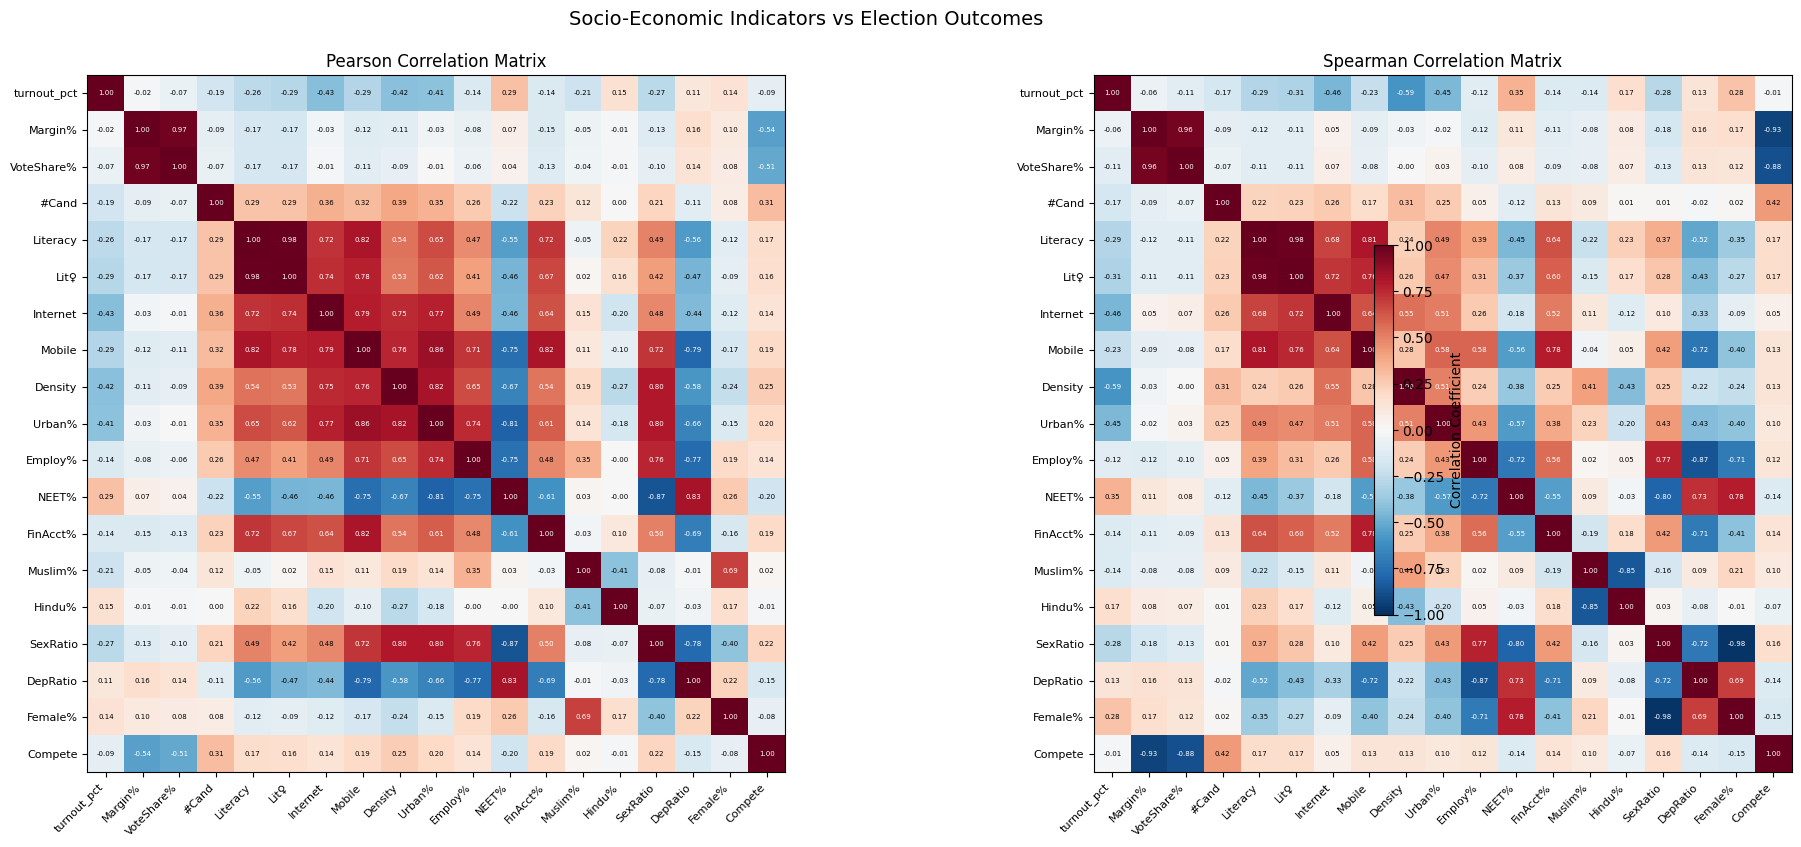

In [18]:
# ── 3A.2  Correlation Heatmap (Visual) ────────────────────────────────────────
import matplotlib.pyplot as plt

# Short labels for readability
SHORT = {
    "winning_margin_pct": "Margin%", "winner_vote_share_pct": "VoteShare%",
    "candidate_count": "#Cand", "literacy_rate": "Literacy",
    "literacy_female": "Lit♀", "internet_pct": "Internet",
    "mobile_phone_pct": "Mobile", "pop_density": "Density",
    "urbanization_index": "Urban%", "employment_rate_pct": "Employ%",
    "neet_pct": "NEET%", "financial_account_pct": "FinAcct%",
    "muslim_majority_pct": "Muslim%", "hindu_pct": "Hindu%",
    "sex_ratio": "SexRatio", "dependency_ratio": "DepRatio",
    "female_pct": "Female%", "competitiveness_index": "Compete"
}
labels = [SHORT.get(f, f) for f in CORR_FEATURES]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, mat, title in zip(axes, [pearson_np, spearman_np], ["Pearson", "Spearman"]):
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(f"{title} Correlation Matrix", fontsize=12)
    # Annotate cells with values
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = mat[i][j]
            color = "white" if abs(v) > 0.5 else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=5, color=color)

fig.colorbar(im, ax=axes, shrink=0.6, label="Correlation Coefficient")
plt.suptitle("Socio-Economic Indicators vs Election Outcomes", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3B – Research Questions (Spark SQL Deep-Dives)

Answering the core questions using Spark SQL queries on `analytics_base`:
- **Q1:** Are religion demographics and winning party correlated?
- **Q2:** How do sex & age demographics relate to winning party?
- **Q3:** How is literacy rate related to voting patterns?

In [19]:
# ── 3B.1  Q1: Are Religion and Winning Party Correlated? ──────────────────────
print("═" * 70)
print("Q1: ARE RELIGION DEMOGRAPHICS AND WINNING PARTY CORRELATED?")
print("═" * 70)

# 1) Average religion share per winning party
print("\n── Party Profile: Average Religion Demographics ──")
spark.sql("""
    SELECT winner_party,
           COUNT(*) AS seats,
           ROUND(AVG(muslim_majority_pct), 2) AS avg_muslim_pct,
           ROUND(AVG(hindu_pct), 2)            AS avg_hindu_pct,
           ROUND(STDDEV(muslim_majority_pct), 2) AS std_muslim_pct,
           ROUND(MIN(muslim_majority_pct), 2)    AS min_muslim,
           ROUND(MAX(muslim_majority_pct), 2)    AS max_muslim
    FROM analytics_base
    GROUP BY winner_party
    ORDER BY seats DESC
""").show(truncate=False)

# 2) Cross-tab: religion band vs winning party
print("── Cross-Tab: Muslim Population Band × Winner Party ──")
spark.sql("""
    SELECT
        CASE
            WHEN muslim_majority_pct >= 95 THEN '95%+ (Very High)'
            WHEN muslim_majority_pct >= 90 THEN '90-95% (High)'
            WHEN muslim_majority_pct >= 80 THEN '80-90% (Moderate)'
            ELSE '<80% (Lower)'
        END AS muslim_band,
        winner_party,
        COUNT(*) AS seats,
        ROUND(AVG(winning_margin_pct), 2) AS avg_margin
    FROM analytics_base
    GROUP BY muslim_band, winner_party
    ORDER BY muslim_band, seats DESC
""").show(30, truncate=False)

# 3) Hindu % quartile vs election competitiveness
print("── Hindu % Quartiles × Election Competitiveness ──")
spark.sql("""
    WITH q AS (
        SELECT *,
               NTILE(4) OVER (ORDER BY hindu_pct) AS hindu_quartile
        FROM analytics_base
    )
    SELECT hindu_quartile AS quartile,
           ROUND(AVG(hindu_pct), 2) AS avg_hindu_pct,
           ROUND(AVG(winning_margin_pct), 2) AS avg_margin,
           ROUND(AVG(competitiveness_index), 2) AS avg_competitiveness,
           COUNT(*) AS constituencies
    FROM q
    GROUP BY hindu_quartile
    ORDER BY hindu_quartile
""").show()

# 4) Correlation coefficients (religion ↔ election outcomes)
idx_muslim = CORR_FEATURES.index("muslim_majority_pct")
idx_hindu  = CORR_FEATURES.index("hindu_pct")
print(f"\n📊 CORRELATION SUMMARY:")
print(f"   muslim%  ↔ winning_margin%:  r = {pearson_np[idx_muslim][idx_margin]:+.4f}  (ρ = {spearman_np[idx_muslim][idx_margin]:+.4f})")
print(f"   hindu%   ↔ winning_margin%:  r = {pearson_np[idx_hindu][idx_margin]:+.4f}  (ρ = {spearman_np[idx_hindu][idx_margin]:+.4f})")
print(f"   muslim%  ↔ vote_share%:      r = {pearson_np[idx_muslim][idx_share]:+.4f}")
print(f"   hindu%   ↔ vote_share%:      r = {pearson_np[idx_hindu][idx_share]:+.4f}")
print(f"\n   ▸ |r| < 0.1 = negligible  |  0.1-0.3 = weak  |  0.3-0.5 = moderate  |  > 0.5 = strong")

══════════════════════════════════════════════════════════════════════
Q1: ARE RELIGION DEMOGRAPHICS AND WINNING PARTY CORRELATED?
══════════════════════════════════════════════════════════════════════

── Party Profile: Average Religion Demographics ──
+---------------------------------+-----+--------------+-------------+--------------+----------+----------+
|winner_party                     |seats|avg_muslim_pct|avg_hindu_pct|std_muslim_pct|min_muslim|max_muslim|
+---------------------------------+-----+--------------+-------------+--------------+----------+----------+
|BNP                              |207  |88.96         |8.71         |11.47         |30.88     |98.35     |
|Bangladesh Jamaat-e-Islami       |68   |90.09         |8.6          |9.15          |30.88     |97.87     |
|Independent                      |8    |91.17         |8.34         |6.19          |78.6      |96.04     |
|National Citizens Party - NCP    |6    |94.09         |6.33         |2.07          |90.64     |95

In [20]:
# ── 3B.2  Q2: Sex / Age Demographics vs Winning Party ─────────────────────────
print("═" * 70)
print("Q2: HOW DO SEX & AGE DEMOGRAPHICS RELATE TO WINNING PARTY?")
print("═" * 70)

# 1) Party profile: sex ratio, dependency ratio, female %
print("\n── Party Profile: Sex & Age Demographics ──")
spark.sql("""
    SELECT winner_party,
           COUNT(*) AS seats,
           ROUND(AVG(sex_ratio), 2)        AS avg_sex_ratio,
           ROUND(AVG(female_pct), 2)       AS avg_female_pct,
           ROUND(AVG(dependency_ratio), 2) AS avg_dep_ratio,
           ROUND(AVG(neet_pct), 2)         AS avg_youth_neet
    FROM analytics_base
    GROUP BY winner_party
    ORDER BY seats DESC
""").show(truncate=False)

# 2) Sex ratio quartile analysis
print("── Sex Ratio Quartiles × Election Outcomes ──")
spark.sql("""
    WITH q AS (
        SELECT *,
               NTILE(4) OVER (ORDER BY sex_ratio) AS sex_q
        FROM analytics_base
    )
    SELECT sex_q AS quartile,
           ROUND(AVG(sex_ratio), 2) AS avg_sex_ratio,
           ROUND(AVG(winning_margin_pct), 2) AS avg_margin,
           ROUND(AVG(winner_vote_share_pct), 2) AS avg_vote_share,
           COUNT(*) AS constituencies
    FROM q
    GROUP BY sex_q
    ORDER BY sex_q
""").show()

# 3) Dependency ratio (age structure proxy) vs outcomes
print("── Dependency Ratio (Age Structure) × Election Outcomes ──")
spark.sql("""
    WITH q AS (
        SELECT *,
               NTILE(4) OVER (ORDER BY dependency_ratio) AS dep_q
        FROM analytics_base
    )
    SELECT dep_q AS quartile,
           ROUND(AVG(dependency_ratio), 2) AS avg_dep_ratio,
           ROUND(AVG(winning_margin_pct), 2) AS avg_margin,
           ROUND(AVG(literacy_rate), 2) AS avg_literacy,
           ROUND(AVG(urbanization_index), 2) AS avg_urban,
           COUNT(*) AS constituencies
    FROM q
    GROUP BY dep_q
    ORDER BY dep_q
""").show()

# 4) Correlations
idx_sex = CORR_FEATURES.index("sex_ratio")
idx_dep = CORR_FEATURES.index("dependency_ratio")
idx_fem = CORR_FEATURES.index("female_pct")
print(f"📊 CORRELATION SUMMARY:")
print(f"   sex_ratio      ↔ margin%:  r = {pearson_np[idx_sex][idx_margin]:+.4f}  (ρ = {spearman_np[idx_sex][idx_margin]:+.4f})")
print(f"   female_pct     ↔ margin%:  r = {pearson_np[idx_fem][idx_margin]:+.4f}  (ρ = {spearman_np[idx_fem][idx_margin]:+.4f})")
print(f"   dep_ratio      ↔ margin%:  r = {pearson_np[idx_dep][idx_margin]:+.4f}  (ρ = {spearman_np[idx_dep][idx_margin]:+.4f})")
print(f"   sex_ratio      ↔ literacy: r = {pearson_np[idx_sex][CORR_FEATURES.index('literacy_rate')]:+.4f}")
print(f"   dep_ratio      ↔ internet: r = {pearson_np[idx_dep][CORR_FEATURES.index('internet_pct')]:+.4f}")

══════════════════════════════════════════════════════════════════════
Q2: HOW DO SEX & AGE DEMOGRAPHICS RELATE TO WINNING PARTY?
══════════════════════════════════════════════════════════════════════

── Party Profile: Sex & Age Demographics ──
+---------------------------------+-----+-------------+--------------+-------------+--------------+
|winner_party                     |seats|avg_sex_ratio|avg_female_pct|avg_dep_ratio|avg_youth_neet|
+---------------------------------+-----+-------------+--------------+-------------+--------------+
|BNP                              |207  |97.32        |50.56         |54.67        |34.95         |
|Bangladesh Jamaat-e-Islami       |68   |99.03        |52.24         |49.92        |33.96         |
|Independent                      |8    |93.05        |51.62         |59.25        |36.61         |
|National Citizens Party - NCP    |6    |99.33        |49.67         |52.65        |34.55         |
|Islamic Andolon Bangladesh       |2    |95.6         

In [21]:
# ── 3B.3  Q3: Literacy Rate and Voting Patterns ───────────────────────────────
print("═" * 70)
print("Q3: HOW IS LITERACY RATE RELATED TO VOTING PATTERNS?")
print("═" * 70)

# 1) Literacy quartiles vs voting outcomes
print("\n── Literacy Quartiles × Voting Outcomes ──")
spark.sql("""
    WITH q AS (
        SELECT *,
               NTILE(4) OVER (ORDER BY literacy_rate) AS lit_q
        FROM analytics_base
    )
    SELECT lit_q AS quartile,
           ROUND(AVG(literacy_rate), 2) AS avg_literacy,
           ROUND(AVG(winning_margin_pct), 2) AS avg_margin,
           ROUND(AVG(winner_vote_share_pct), 2) AS avg_vote_share,
           ROUND(AVG(competitiveness_index), 2) AS avg_competitiveness,
           ROUND(AVG(candidate_count), 1) AS avg_candidates,
           COUNT(*) AS constituencies
    FROM q
    GROUP BY lit_q
    ORDER BY lit_q
""").show()

# 2) Literacy vs winning party
print("── Average Literacy by Winning Party ──")
spark.sql("""
    SELECT winner_party,
           COUNT(*) AS seats,
           ROUND(AVG(literacy_rate), 2) AS avg_literacy,
           ROUND(AVG(literacy_female), 2) AS avg_lit_female,
           ROUND(AVG(internet_pct), 2) AS avg_internet,
           ROUND(AVG(urbanization_index), 2) AS avg_urban
    FROM analytics_base
    GROUP BY winner_party
    ORDER BY seats DESC
""").show(truncate=False)

# 3) Gender literacy gap vs election outcomes
print("── Female Literacy Gap × Voting ──")
spark.sql("""
    WITH q AS (
        SELECT *,
               (literacy_rate - literacy_female) AS literacy_gap,
               NTILE(4) OVER (ORDER BY (literacy_rate - literacy_female)) AS gap_q
        FROM analytics_base
    )
    SELECT gap_q AS quartile,
           ROUND(AVG(literacy_gap), 2) AS avg_gender_gap,
           ROUND(AVG(winning_margin_pct), 2) AS avg_margin,
           ROUND(AVG(female_pct), 2) AS avg_female_pct,
           COUNT(*) AS n
    FROM q
    GROUP BY gap_q
    ORDER BY gap_q
""").show()

# 4) Correlations
idx_lit  = CORR_FEATURES.index("literacy_rate")
idx_litf = CORR_FEATURES.index("literacy_female")
idx_inet = CORR_FEATURES.index("internet_pct")
print(f"📊 CORRELATION SUMMARY:")
print(f"   literacy       ↔ margin%:      r = {pearson_np[idx_lit][idx_margin]:+.4f}  (ρ = {spearman_np[idx_lit][idx_margin]:+.4f})")
print(f"   literacy_fem   ↔ margin%:      r = {pearson_np[idx_litf][idx_margin]:+.4f}  (ρ = {spearman_np[idx_litf][idx_margin]:+.4f})")
print(f"   internet       ↔ margin%:      r = {pearson_np[idx_inet][idx_margin]:+.4f}  (ρ = {spearman_np[idx_inet][idx_margin]:+.4f})")
print(f"   literacy       ↔ vote_share%:  r = {pearson_np[idx_lit][idx_share]:+.4f}")
print(f"   literacy       ↔ internet:     r = {pearson_np[idx_lit][idx_inet]:+.4f}  (co-development indicator)")

══════════════════════════════════════════════════════════════════════
Q3: HOW IS LITERACY RATE RELATED TO VOTING PATTERNS?
══════════════════════════════════════════════════════════════════════

── Literacy Quartiles × Voting Outcomes ──
+--------+------------+----------+--------------+-------------------+--------------+--------------+
|quartile|avg_literacy|avg_margin|avg_vote_share|avg_competitiveness|avg_candidates|constituencies|
+--------+------------+----------+--------------+-------------------+--------------+--------------+
|       1|       67.52|     24.74|         62.01|               0.57|           6.1|            75|
|       2|       71.99|     18.53|         58.31|               0.71|           6.2|            75|
|       3|       76.16|     20.76|         59.97|               0.66|           6.6|            75|
|       4|       82.08|      17.9|         58.41|               0.99|           7.8|            74|
+--------+------------+----------+--------------+------------

### 3C - Predictive Models (Spark MLlib)

- **Linear Regression:** Which socio-economic factors predict voter turnout?
- **Random Forest Classification:** Can we predict the winning party from socio-economic profile alone?
- **KMeans Clustering:** Are there natural constituency clusters based on demographics?

In [22]:
# -- 3C.1  Linear Regression - Predict Voter Turnout % ------------------------
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

print("=" * 70)
print("LINEAR REGRESSION: Predicting turnout_pct")
print("  -> Which socio-economic factors predict voter turnout?")
print("=" * 70)

REG_FEATURES = [
    "literacy_rate", "literacy_female", "internet_pct",
    "pop_density", "urbanization_index", "employment_rate_pct",
    "neet_pct", "financial_account_pct",
    "muslim_majority_pct", "hindu_pct",
    "sex_ratio", "dependency_ratio", "female_pct",
    "mobile_phone_pct", "candidate_count"
]

reg_data = analytics_base.select(REG_FEATURES + ["turnout_pct"]).dropna()
print(f"Regression dataset: {reg_data.count()} rows")

# Train / test split (80/20)
train, test = reg_data.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train.count()} | Test: {test.count()}")

# Pipeline: VectorAssembler -> StandardScaler -> LinearRegression
assembler = VectorAssembler(inputCols=REG_FEATURES, outputCol="raw_features")
scaler = StandardScaler(inputCol="raw_features", outputCol="features",
                        withMean=True, withStd=True)
lr = LinearRegression(featuresCol="features", labelCol="turnout_pct",
                      maxIter=100, regParam=0.1, elasticNetParam=0.5)

pipeline = Pipeline(stages=[assembler, scaler, lr])
lr_pipeline_model = pipeline.fit(train)

# Evaluate
lr_predictions = lr_pipeline_model.transform(test)
r2   = RegressionEvaluator(labelCol="turnout_pct", metricName="r2").evaluate(lr_predictions)
rmse = RegressionEvaluator(labelCol="turnout_pct", metricName="rmse").evaluate(lr_predictions)

print(f"\nMODEL PERFORMANCE:")
print(f"   R2 (coefficient of determination): {r2:.4f}")
print(f"   RMSE (root mean squared error):    {rmse:.4f}")

# Coefficients - which features matter most?
lr_model = lr_pipeline_model.stages[-1]
coefficients = sorted(zip(REG_FEATURES, lr_model.coefficients.toArray()),
                      key=lambda x: abs(x[1]), reverse=True)

print(f"\nFEATURE IMPORTANCE (standardized coefficients):")
print(f"   Intercept: {lr_model.intercept:.4f}")
for feat, coef in coefficients:
    direction = "higher turnout" if coef > 0 else "lower turnout"
    bar = "#" * int(abs(coef) * 5)
    print(f"   {feat:30s}  beta = {coef:+.4f}  {bar}  {direction}")

# Sample predictions
print("\nSample Predictions vs Actual:")
lr_predictions.select(
    "turnout_pct", "prediction",
    "literacy_rate", "muslim_majority_pct", "sex_ratio"
).show(10, truncate=False)

LINEAR REGRESSION: Predicting turnout_pct
  -> Which socio-economic factors predict voter turnout?
Regression dataset: 279 rows
Train: 237 | Test: 42

MODEL PERFORMANCE:
   R2 (coefficient of determination): 0.4709
   RMSE (root mean squared error):    5.5164

FEATURE IMPORTANCE (standardized coefficients):
   Intercept: 9.3207
   muslim_majority_pct             beta = -5.5220  ###########################  lower turnout
   female_pct                      beta = +3.9052  ###################  higher turnout
   neet_pct                        beta = +3.5669  #################  higher turnout
   employment_rate_pct             beta = +3.0458  ###############  higher turnout
   hindu_pct                       beta = -2.6387  #############  lower turnout
   internet_pct                    beta = -2.5625  ############  lower turnout
   dependency_ratio                beta = -1.8596  #########  lower turnout
   urbanization_index              beta = -1.6988  ########  lower turnout
   financia

In [23]:
# ── 3C.2  Random Forest Classification — Predict Winning Party ────────────────
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.feature import StringIndexer, IndexToString
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print("═" * 70)
print("RANDOM FOREST CLASSIFIER: Predicting winner_party")
print("  → Can we predict the winning party from socio-economics alone?")
print("═" * 70)

# Use only socio-economic features (no election-derived features = no data leakage)
CLF_FEATURES = [
    "literacy_rate", "literacy_female", "internet_pct",
    "pop_density", "urbanization_index", "employment_rate_pct",
    "neet_pct", "financial_account_pct",
    "muslim_majority_pct", "hindu_pct",
    "sex_ratio", "dependency_ratio", "female_pct",
    "mobile_phone_pct", "candidate_count"
]

clf_data = analytics_base.select(CLF_FEATURES + ["winner_party"]).dropna()
print(f"Classification dataset: {clf_data.count()} rows")

train_c, test_c = clf_data.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_c.count()} | Test: {test_c.count()}")

# Pipeline: StringIndexer → VectorAssembler → RandomForest
label_indexer = StringIndexer(inputCol="winner_party", outputCol="label",
                              handleInvalid="keep")
assembler = VectorAssembler(inputCols=CLF_FEATURES, outputCol="features")
rf = RandomForestClassifier(featuresCol="features", labelCol="label",
                            numTrees=100, maxDepth=5, seed=42)

pipeline = Pipeline(stages=[label_indexer, assembler, rf])
clf_model = pipeline.fit(train_c)

# Get party label mapping
party_labels = clf_model.stages[0].labels
print(f"Party labels (by frequency): {list(party_labels)}")

# Predict & add readable labels
clf_preds = clf_model.transform(test_c)
converter = IndexToString(inputCol="prediction", outputCol="predicted_party",
                          labels=party_labels)
clf_preds = converter.transform(clf_preds)

# Evaluate
print(f"\n📊 CLASSIFICATION METRICS:")
for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
    ev = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName=metric)
    print(f"   {metric:25s}: {ev.evaluate(clf_preds):.4f}")

# Feature importance (Gini)
rf_model = clf_model.stages[-1]
importances = sorted(zip(CLF_FEATURES, rf_model.featureImportances.toArray()),
                     key=lambda x: x[1], reverse=True)
print(f"\n📊 FEATURE IMPORTANCE (Gini importance — what best separates parties):")
for feat, imp in importances:
    bar = "█" * int(imp * 80)
    print(f"   {feat:30s}  {imp:.4f}  {bar}")

# Confusion matrix via Spark SQL
clf_preds.createOrReplaceTempView("clf_preds")
print("\n── Confusion Matrix ──")
spark.sql("""
    SELECT winner_party AS actual, predicted_party AS predicted, COUNT(*) AS n
    FROM clf_preds
    GROUP BY winner_party, predicted_party
    ORDER BY actual, predicted
""").show(30, truncate=False)

══════════════════════════════════════════════════════════════════════
RANDOM FOREST CLASSIFIER: Predicting winner_party
  → Can we predict the winning party from socio-economics alone?
══════════════════════════════════════════════════════════════════════
Classification dataset: 279 rows
Train: 237 | Test: 42
Party labels (by frequency): ['BNP', 'Bangladesh Jamaat-e-Islami', 'Independent', 'National Citizens Party - NCP', 'Bangladesh Khilafat Majlis', 'Gono Odhikar Parishad', 'Bangladesh National Party - BJP', 'Ganosamhati Andolon', 'Islamic Andolon Bangladesh', 'Jatiya Samajtantrik Dal (JSD Rab)', 'Khilafat Majlis']

📊 CLASSIFICATION METRICS:
   accuracy                 : 0.7619
   weightedPrecision        : 0.6481
   weightedRecall           : 0.7619
   f1                       : 0.6974

📊 FEATURE IMPORTANCE (Gini importance — what best separates parties):
   employment_rate_pct             0.0992  ███████
   dependency_ratio                0.0967  ███████
   candidate_count        

In [24]:
# ── 3C.3  KMeans Clustering — Group Constituencies by Socio Profile ───────────
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print("═" * 70)
print("KMEANS CLUSTERING: Grouping constituencies by socio-economic profile")
print("═" * 70)

CLUSTER_FEATURES = [
    "literacy_rate", "internet_pct", "pop_density",
    "urbanization_index", "employment_rate_pct", "neet_pct",
    "financial_account_pct", "muslim_majority_pct",
    "sex_ratio", "dependency_ratio", "female_pct"
]

cluster_data = analytics_base.select(
    ["constituency", "district", "division", "winner_party",
     "winning_margin_pct"] + CLUSTER_FEATURES
).dropna()
print(f"Clustering dataset: {cluster_data.count()} rows")

assembler = VectorAssembler(inputCols=CLUSTER_FEATURES, outputCol="raw_features")
scaler = StandardScaler(inputCol="raw_features", outputCol="features",
                        withMean=True, withStd=True)

# Elbow method: try k = 2 to 8
print("\n── Silhouette Scores by k ──")
scores = []
for k in range(2, 9):
    kmeans = KMeans(featuresCol="features", k=k, seed=42, maxIter=30)
    pipe = Pipeline(stages=[assembler, scaler, kmeans])
    km_model = pipe.fit(cluster_data)
    preds = km_model.transform(cluster_data)
    sil = ClusteringEvaluator(featuresCol="features").evaluate(preds)
    scores.append((k, sil))
    print(f"   k={k}: silhouette = {sil:.4f}")

best_k = max(scores, key=lambda x: x[1])[0]
print(f"\n✓ Best k = {best_k} (highest silhouette score)")

# Fit final model with best k
kmeans_final = KMeans(featuresCol="features", k=best_k, seed=42, maxIter=50)
pipe_final = Pipeline(stages=[assembler, scaler, kmeans_final])
km_final_model = pipe_final.fit(cluster_data)
clustered = km_final_model.transform(cluster_data)
clustered.createOrReplaceTempView("clustered")

# Cluster profiles
print(f"\n── Cluster Profiles (k={best_k}) ──")
spark.sql("""
    SELECT prediction AS cluster,
           COUNT(*) AS constituencies,
           ROUND(AVG(literacy_rate), 2) AS avg_literacy,
           ROUND(AVG(internet_pct), 2) AS avg_internet,
           ROUND(AVG(urbanization_index), 2) AS avg_urban,
           ROUND(AVG(pop_density), 2) AS avg_density,
           ROUND(AVG(muslim_majority_pct), 2) AS avg_muslim_pct,
           ROUND(AVG(dependency_ratio), 2) AS avg_dep_ratio,
           ROUND(AVG(winning_margin_pct), 2) AS avg_margin
    FROM clustered
    GROUP BY prediction
    ORDER BY prediction
""").show(truncate=False)

# Dominant party per cluster
print("── Party Distribution per Cluster ──")
spark.sql("""
    SELECT prediction AS cluster, winner_party, COUNT(*) AS seats
    FROM clustered
    GROUP BY prediction, winner_party
    ORDER BY prediction, seats DESC
""").show(30, truncate=False)

══════════════════════════════════════════════════════════════════════
KMEANS CLUSTERING: Grouping constituencies by socio-economic profile
══════════════════════════════════════════════════════════════════════
Clustering dataset: 275 rows

── Silhouette Scores by k ──
   k=2: silhouette = 0.7030
   k=3: silhouette = 0.5144
   k=4: silhouette = 0.6143
   k=5: silhouette = 0.4654
   k=6: silhouette = 0.5099
   k=7: silhouette = 0.4633
   k=8: silhouette = 0.4048

✓ Best k = 2 (highest silhouette score)

── Cluster Profiles (k=2) ──
+-------+--------------+------------+------------+---------+-----------+--------------+-------------+----------+
|cluster|constituencies|avg_literacy|avg_internet|avg_urban|avg_density|avg_muslim_pct|avg_dep_ratio|avg_margin|
+-------+--------------+------------+------------+---------+-----------+--------------+-------------+----------+
|0      |231           |72.82       |26.28       |23.17    |1115.37    |88.91         |55.79        |20.7      |
|1      |44

In [25]:
# -- 3C.4  Export All ML Artifacts ---------------------------------------------
import json

OUTPUT_DIR = f"{DATA_ROOT}/processed/spark_output"

# 1) Correlation matrices -> CSV
import pandas as pd
pearson_pdf = pd.DataFrame(pearson_np, columns=CORR_FEATURES, index=CORR_FEATURES)
pearson_pdf.to_csv(f"{OUTPUT_DIR}/pearson_correlation.csv")
spearman_pdf = pd.DataFrame(spearman_np, columns=CORR_FEATURES, index=CORR_FEATURES)
spearman_pdf.to_csv(f"{OUTPUT_DIR}/spearman_correlation.csv")

# 2) Regression results -> JSON
reg_results = {
    "model": "LinearRegression",
    "target": "turnout_pct",
    "r2": round(r2, 4),
    "rmse": round(rmse, 4),
    "intercept": round(float(lr_model.intercept), 4),
    "coefficients": {f: round(float(c), 4)
                     for f, c in zip(REG_FEATURES, lr_model.coefficients.toArray())},
    "features": REG_FEATURES
}
with open(f"{OUTPUT_DIR}/regression_results.json", "w") as f:
    json.dump(reg_results, f, indent=2)

# 3) Classification results -> JSON
clf_metrics = {}
for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
    ev = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName=metric)
    clf_metrics[metric] = round(ev.evaluate(clf_preds), 4)

clf_results = {
    "model": "RandomForestClassifier",
    "target": "winner_party",
    "num_trees": 100, "max_depth": 5,
    "party_labels": list(party_labels),
    "metrics": clf_metrics,
    "feature_importance": {f: round(float(i), 4) for f, i in importances}
}
with open(f"{OUTPUT_DIR}/classification_results.json", "w") as f:
    json.dump(clf_results, f, indent=2)

# 4) Cluster assignments -> CSV
clustered.select("constituency", "district", "division", "winner_party", "prediction") \
    .coalesce(1).write.mode("overwrite").option("header", "true") \
    .csv(f"{OUTPUT_DIR}/cluster_assignments_csv")

# 5) Cluster profiles -> JSON
cluster_rows = spark.sql("""
    SELECT prediction AS cluster, COUNT(*) AS n,
           ROUND(AVG(literacy_rate), 2) AS avg_literacy,
           ROUND(AVG(internet_pct), 2) AS avg_internet,
           ROUND(AVG(urbanization_index), 2) AS avg_urban,
           ROUND(AVG(pop_density), 2) AS avg_density,
           ROUND(AVG(muslim_majority_pct), 2) AS avg_muslim,
           ROUND(AVG(winning_margin_pct), 2) AS avg_margin
    FROM clustered GROUP BY prediction ORDER BY prediction
""").collect()
with open(f"{OUTPUT_DIR}/cluster_profiles.json", "w") as f:
    json.dump([row.asDict() for row in cluster_rows], f, indent=2)

# 6) Analytics base (updated with new features) -> Parquet & CSV
analytics_base.coalesce(1).write.mode("overwrite").parquet(f"{OUTPUT_DIR}/analytics_base.parquet")
analytics_base.coalesce(1).write.mode("overwrite").option("header", "true") \
    .csv(f"{OUTPUT_DIR}/analytics_base_csv")

print(f"All ML artifacts exported to {OUTPUT_DIR}/")
print(f"  - pearson_correlation.csv")
print(f"  - spearman_correlation.csv")
print(f"  - regression_results.json")
print(f"  - classification_results.json")
print(f"  - cluster_assignments_csv/")
print(f"  - cluster_profiles.json")
print(f"  - analytics_base.parquet")
print(f"  - analytics_base_csv/")
print(f"\n{'=' * 60}")
print("Phase 3 COMPLETE - All MLlib analytics finished")
print(f"{'=' * 60}")

All ML artifacts exported to /content/drive/MyDrive/Election-Data/data/processed/spark_output/
  - pearson_correlation.csv
  - spearman_correlation.csv
  - regression_results.json
  - classification_results.json
  - cluster_assignments_csv/
  - cluster_profiles.json
  - analytics_base.parquet
  - analytics_base_csv/

Phase 3 COMPLETE - All MLlib analytics finished
